In [1]:
import sys
sys.path.append('../src')

In [2]:
from extract import extrair_dados
from scoring import gera_score
from segmentacao import gera_segmentacao
import matplotlib.pyplot as plt

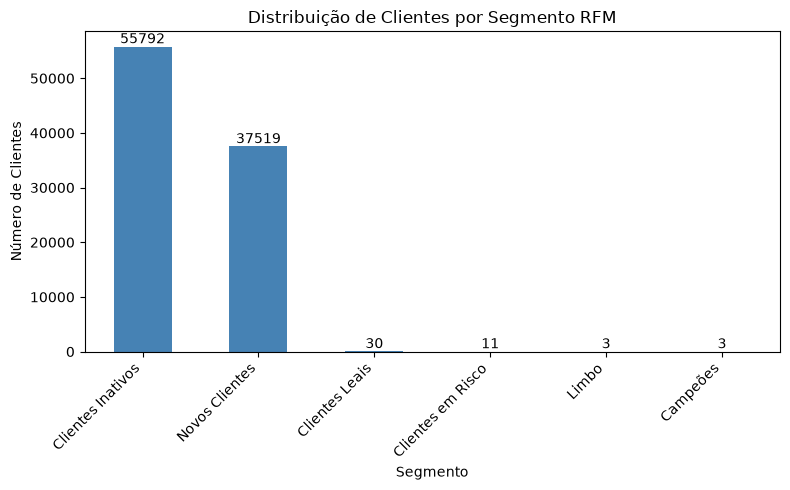

In [18]:
df_rfm = extrair_dados()
df_rfm = gera_score(df_rfm)
df_rfm = gera_segmentacao(df_rfm)

contagem_segmentos = df_rfm['segmento'].value_counts()

grafico = contagem_segmentos.plot(kind='bar', figsize=(8, 5), color='steelblue')

plt.title('Distribuição de Clientes por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.bar_label(grafico.containers[0])

plt.show()

In [ ]:
"""
Essa primeira exibição mostra uma desproporção grande entre os dois principais grupos (clientes inativos e novos clientes) e os demais grupos.
"""

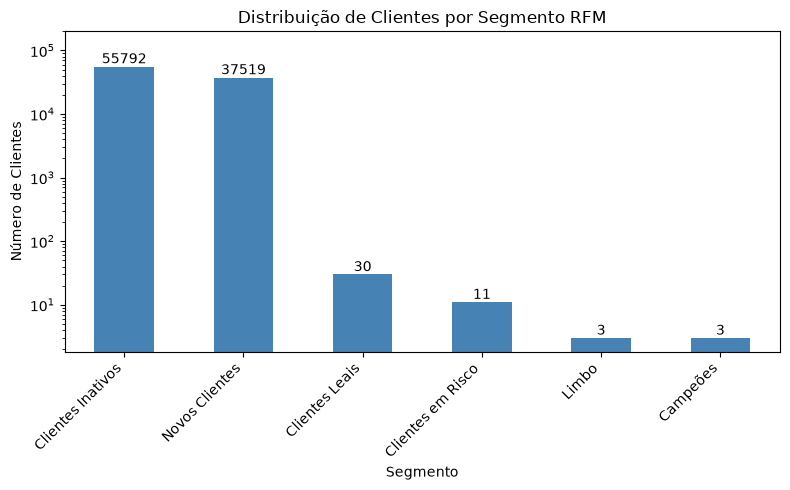

In [15]:
# aplicando escala logarítmica para facilitar a visualização dos grupos que ficaram muito pequenos na escala anterior

df_rfm = extrair_dados()
df_rfm = gera_score(df_rfm)
df_rfm = gera_segmentacao(df_rfm)

contagem_segmentos = df_rfm['segmento'].value_counts()

grafico = contagem_segmentos.plot(kind='bar', figsize=(8, 5), color='steelblue')

plt.title('Distribuição de Clientes por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.bar_label(grafico.containers[0])
plt.ylim(top=200000)

plt.show()

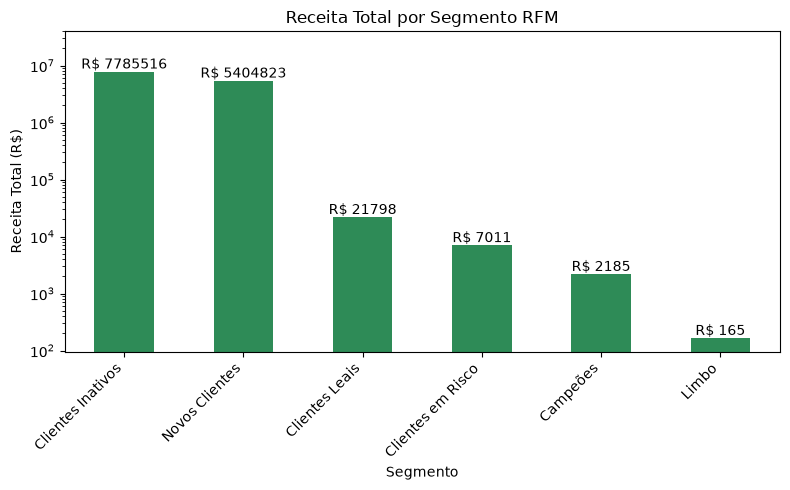

In [19]:
# entendendo a baixa recompra

receita_por_segmento = df_rfm.groupby('segmento')['total_price_per_client'].sum().sort_values(ascending=False)

grafico2 = receita_por_segmento.plot(kind='bar', figsize=(8, 5), color='seagreen')

plt.title('Receita Total por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Receita Total (R$)')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(top=plt.ylim()[1] * 3)
plt.bar_label(grafico2.containers[0], fmt='R$ %.0f')

plt.show()

In [ ]:
"""
Clientes inativos e novos clientes são a maioria. Faz sentido sustentarem a receita total.
"""

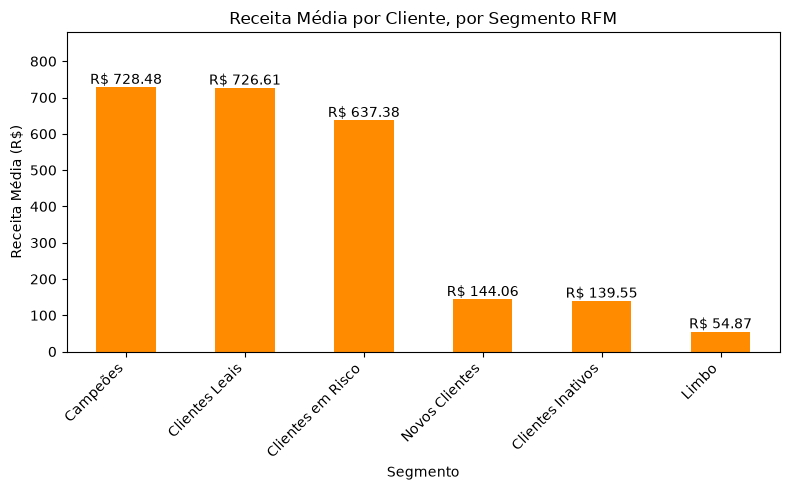

In [20]:
receita_media_por_segmento = df_rfm.groupby('segmento')['total_price_per_client'].mean().sort_values(ascending=False)

grafico3 = receita_media_por_segmento.plot(kind='bar', figsize=(8, 5), color='darkorange')

plt.title('Receita Média por Cliente, por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Receita Média (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(top=plt.ylim()[1] * 1.15)
plt.bar_label(grafico3.containers[0], fmt='R$ %.2f')

plt.show()

In [ ]:
"""
Individualmente, os campeões, leais e em risco valem mais, mas como representam uma pequena parte do todo eles não contribuem em quase nada para a receita total. Os novos clientes e clientes inativos
têm baixo valor individual, mas sustentam o faturamento total por serem a maioria.
"""